In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
aln = ALNModel()

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln = ALNModel()

aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

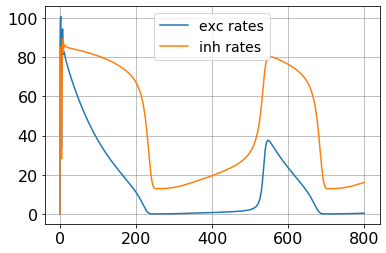

In [4]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

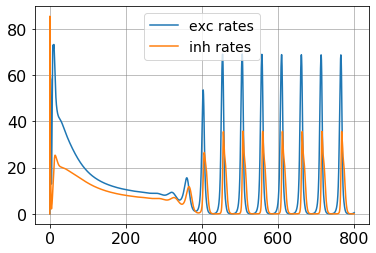

In [5]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

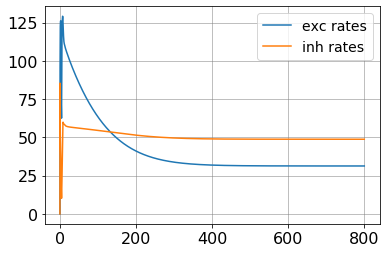

[31.3074 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

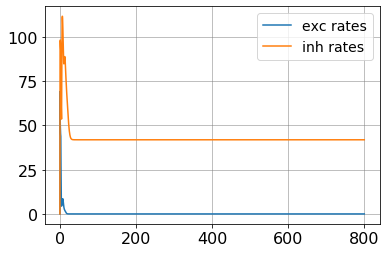

[4.4544e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

### C.a

In [8]:
dur = 1000
dur_pre = 400
dur_post = 400
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

set_params_fast()

control0 = aln.getZeroControl()

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = down_rates[0]
target[:,1,:] = down_rates[1]

tol = 1e-12
start_step = 10.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [9]:
# C.a.1) fast osc => low, max current 1nA, precision only
case = "Ca1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
min_cntrl = - max_cntrl
cntrl_vars = [0,1]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 30

setinit(fast_osc_init)

control0 = aln.getZeroControl()
#control1 = bestControlCa1[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCa1, bestStateCa1, costCa1, runtimeCa1, gradCa1 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultCa1 = {"Opt_control": bestControlCa1,
              "Opt_state": bestStateCa1,
              "costArray": costCa1,
              "runtimeArray": runtimeCa1,    
}

dump_dicts = [opt_params, aln.params, resultCa1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  944778.9286770354


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  944778.9286770334
Control only changes marginally.
RUN  1 , total integrated cost =  944778.9286770334
Improved over  1  iterations by  2.1316282072803006e-13  percent.
Problem in initial value trasfer:  Vmean_exc -65.29494721454402 -65.32658383940712
Problem in initial value trasfer:  Vmean_exc -62.78161906977812 -62.736219735885115


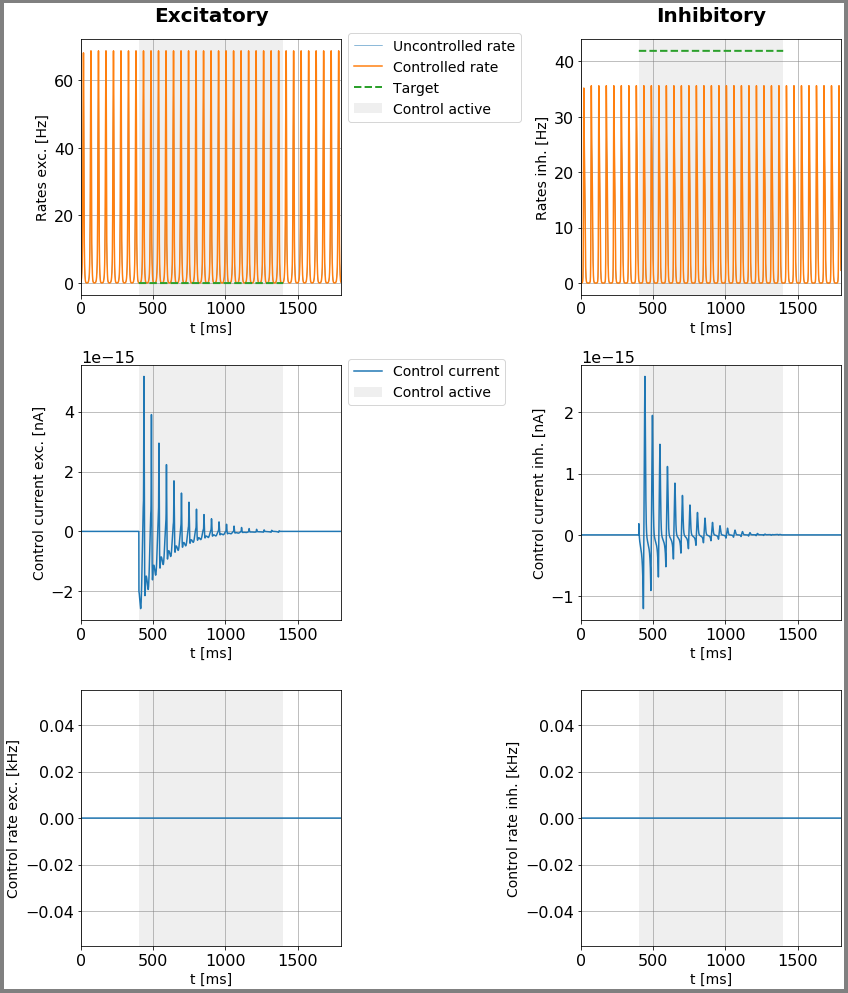

In [10]:
plotFunc.plot_control(aln, bestControlCa1, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

In [11]:
# C.a.2) fast osc => low, max current 1nA, precision + energy + sparsity
case = "Ca2"
cost.setParams(1.0, 10.0, 10.0)
max_cntrl = 1. * 5.
min_cntrl = - max_cntrl
cntrl_vars = [0,1]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 20

setinit(fast_osc_init)
control0 = aln.getZeroControl()
control1 = bestControlCa1[:,:,n_pre-1:-n_pre+1]
#control2 = bestControlCa2[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCa2, bestStateCa2, costCa2, runtimeCa2, gradCa2 = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultCa2 = {"Opt_control": bestControlCa2,
              "Opt_state": bestStateCa2,
              "costArray": costCa2,
              "runtimeArray": runtimeCa2,    
}

dump_dicts = [opt_params, aln.params, resultCa2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  944778.9286770334


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  944778.9286770327
Control only changes marginally.
RUN  1 , total integrated cost =  944778.9286770327
Improved over  1  iterations by  7.105427357601002e-14  percent.
Problem in initial value trasfer:  Vmean_exc -65.29494721454402 -65.32658383940712
Problem in initial value trasfer:  Vmean_exc -62.781619069778515 -62.73621973588503


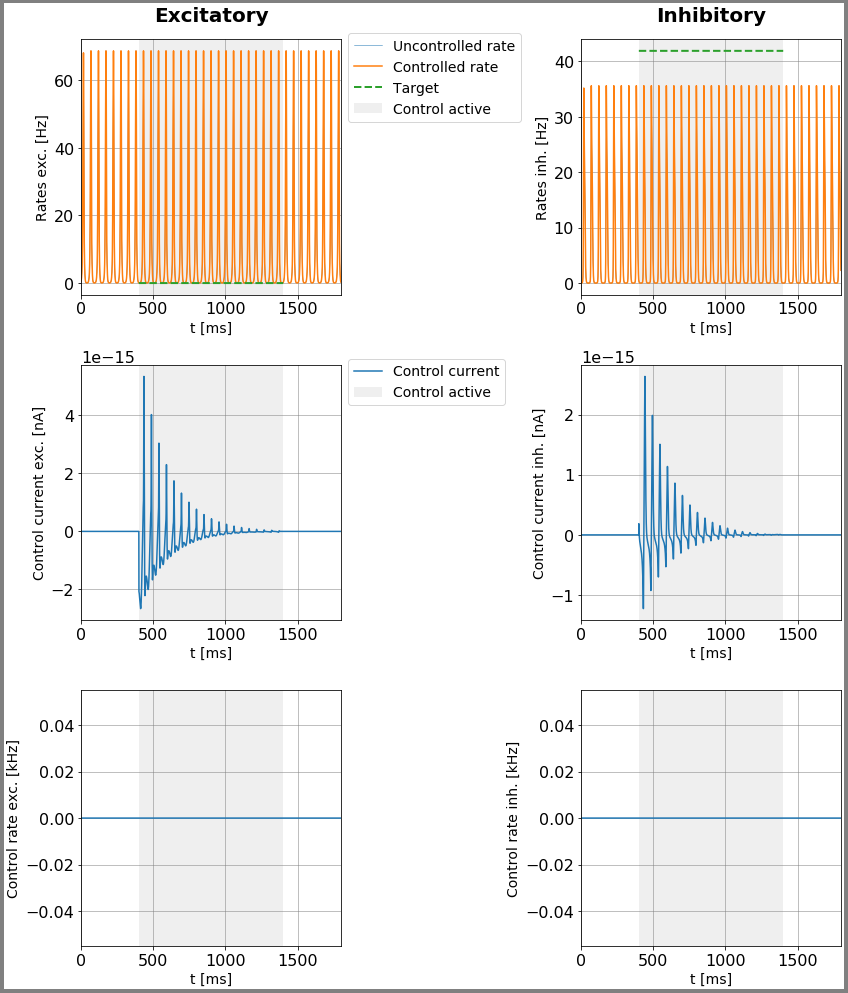

In [12]:
plotFunc.plot_control(aln, bestControlCa2, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

In [13]:
# C.a.3) fast osc => low, max rate 0.1 kHz, precision only
case = "Ca3"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 0.1
min_cntrl = 0.
cntrl_vars = [2]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 30

setinit(fast_osc_init)

control0 = aln.getZeroControl()
#control1 = bestControlCa3[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCa3, bestStateCa3, costCa3, runtimeCa3, gradCa3 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultCa3 = {"Opt_control": bestControlCa3,
              "Opt_state": bestStateCa3,
              "costArray": costCa3,
              "runtimeArray": runtimeCa3,    
}

dump_dicts = [opt_params, aln.params, resultCa3]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  944778.9286770354


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  944778.9286770354
Control only changes marginally.
RUN  1 , total integrated cost =  944778.9286770354
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.29494721454402 -65.32658383940712
Problem in initial value trasfer:  Vmean_exc -62.78161906977759 -62.736219735885186


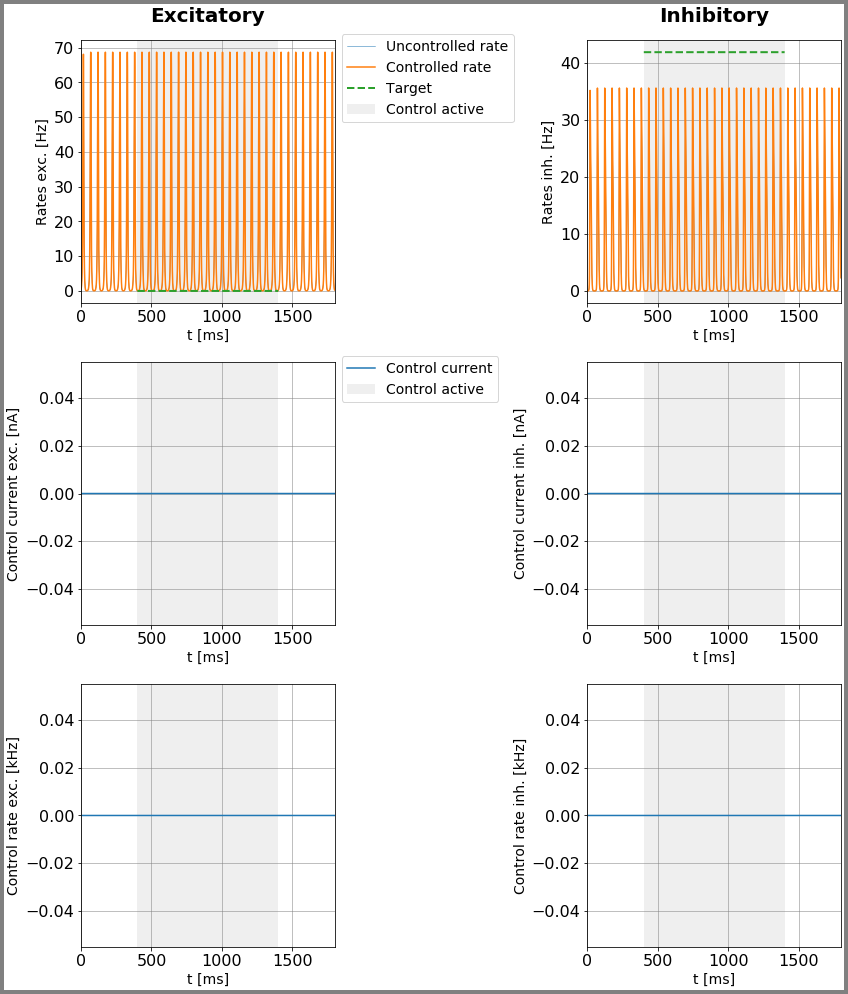

In [14]:
plotFunc.plot_control(aln, bestControlCa3, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

In [15]:
# C.a.4) fast osc => low, max rate 0.1 kHz, precision + energy + sparsity
case = "Ca4"
cost.setParams(1.0, 10.0, 10.0)
max_cntrl = 0.1
min_cntrl = 0.
cntrl_vars = [2]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 20

setinit(fast_osc_init)

control0 = aln.getZeroControl()
control1 = bestControlCa3[:,:,n_pre-1:-n_pre+1]
#control2 = bestControlCa4[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCa4, bestStateCa4, costCa4, runtimeCa4, gradCa4 = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultCa4 = {"Opt_control": bestControlCa4,
              "Opt_state": bestStateCa4,
              "costArray": costCa4,
              "runtimeArray": runtimeCa4,    
}

dump_dicts = [opt_params, aln.params, resultCa4]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  944778.9286770354


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  944778.9286770354
Control only changes marginally.
RUN  1 , total integrated cost =  944778.9286770354
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.29494721454402 -65.32658383940712
Problem in initial value trasfer:  Vmean_exc -62.78161906977759 -62.736219735885186


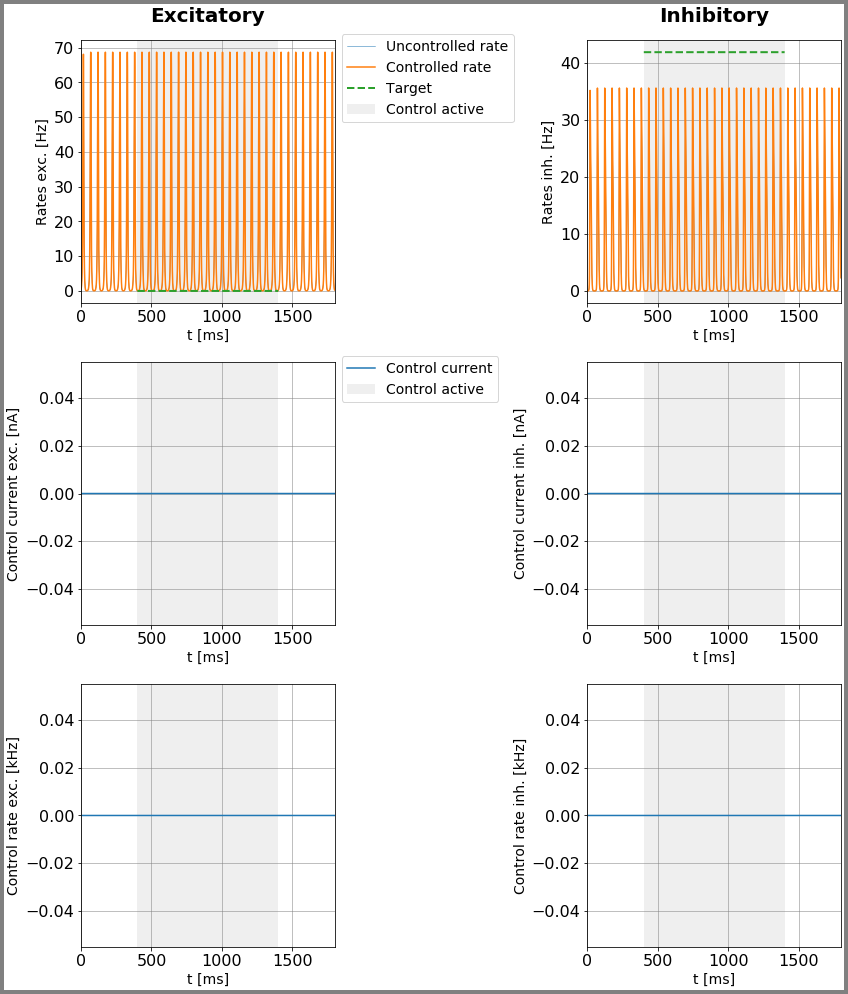

In [16]:
plotFunc.plot_control(aln, bestControlCa4, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

### C.b

In [17]:
dur = 1000
dur_pre = 400
dur_post = 400
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = down_rates[0]
target[:,1,:] = down_rates[1]

set_params_slow()

In [18]:
# C.b.1) slow osc => low, max current 1nA, precision only
case = "Cb1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
min_cntrl = - max_cntrl
cntrl_vars = [0,1]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 30

set_params_slow()
setinit(slow_osc_init)

control0 = aln.getZeroControl()
#control1 = bestControlCb1[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCb1, bestStateCb1, costCb1, runtimeCb1, gradCb1 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultCb1 = {"Opt_control": bestControlCb1,
              "Opt_state": bestStateCb1,
              "costArray": costCb1,
              "runtimeArray": runtimeCb1,    
}

dump_dicts = [opt_params, aln.params, resultCb1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  413693.0889295797
RUN  1 , total integrated cost =  413592.40482748474
RUN  2 , total integrated cost =  413542.2828260653
RUN  3 , total integrated cost =  413514.4524821772
RUN  4 , total integrated cost =  413498.33358759066
RUN  5 , total integrated cost =  413488.24832184426
RUN  6 , total integrated cost =  413481.60443728097
RUN  7 , total integrated cost =  413477.25447910995
RUN  8 , total integrated cost =  413474.2484624519
RUN  9 , total integrated cost =  413472.06532199326
RUN  10 , total integrated cost =  413470.43645665434
RUN  11 , total integrated cost =  413469.32718911924
RUN  12 , total integrated cost =  413468.5157977232
RUN  13 , total integrated cost =  413467.961520739
RUN  14 , total integrated cost =  413467.48042561044
RUN  15 , total integrated cost =  413467.1164095596
RUN  16 , total integrated cost =  413466.80298654333
RUN  17 , total integrated cost =  413466.55961757177
RUN  18 , total integrated cos

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  413464.4850946708
RUN  30 , total integrated cost =  413464.4850946708
Improved over  30  iterations by  0.05525928303525518  percent.
Problem in initial value trasfer:  Vmean_exc -64.30976520510508 -64.30438068639066
Problem in initial value trasfer:  Vmean_exc -61.76697754294267 -61.76499299098285


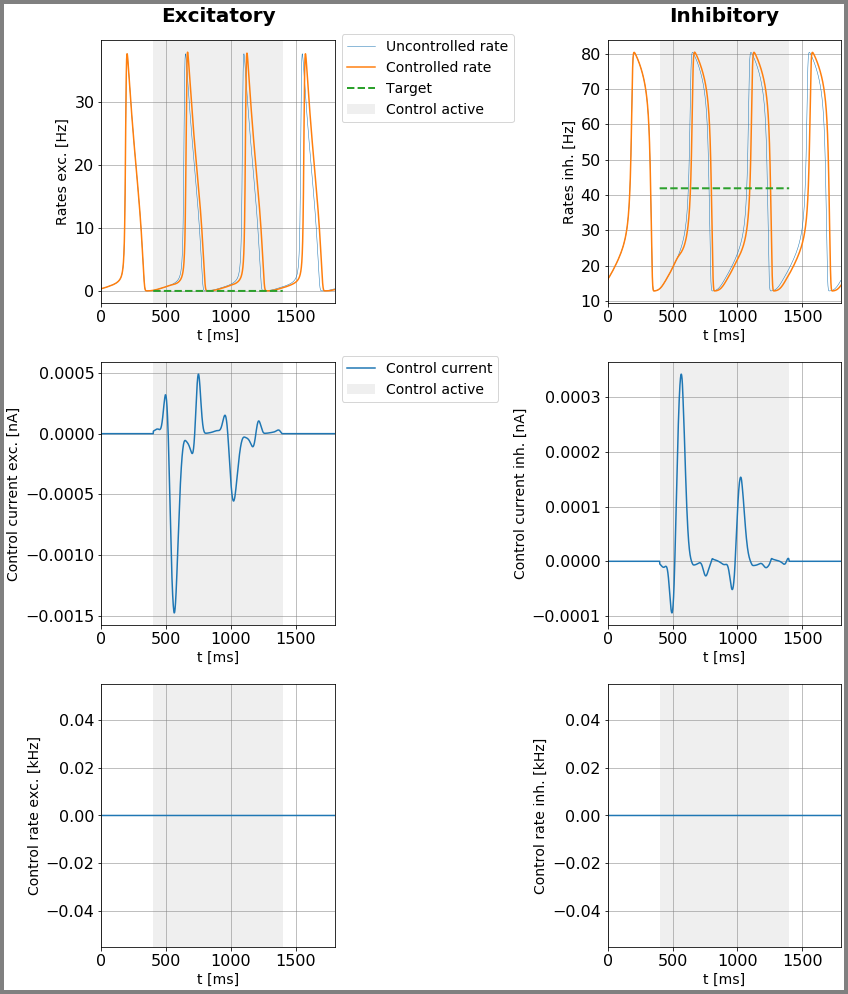

In [19]:
plotFunc.plot_control(aln, bestControlCb1, dur, dur_pre, dur_post, slow_osc_init, target,
                      path, filename_ = case )

In [ ]:
# C.b.2) slow osc => low, max current 1nA, precision + energy + sparsity
case = "Cb2"
cost.setParams(1.0, 10.0, 10.0)
max_cntrl = 1. * 5.
min_cntrl = - max_cntrl
cntrl_vars = [0,1]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 20

setinit(slow_osc_init)

control0 = aln.getZeroControl()
control1 = bestControlCb1[:,:,n_pre-1:-n_pre+1]
#control2 = bestControlCb2[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCb2, bestStateCb2, costCb2, runtimeCb2, gradCb2 = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultCb2 = {"Opt_control": bestControlCb2,
              "Opt_state": bestStateCb2,
              "costArray": costCb2,
              "runtimeArray": runtimeCb2,    
}

dump_dicts = [opt_params, aln.params, resultCb2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  413465.20628086675
RUN  1 , total integrated cost =  413465.10495268117
RUN  2 , total integrated cost =  413464.9923489559
RUN  3 , total integrated cost =  413464.9061828153
RUN  4 , total integrated cost =  413464.78223695577


In [ ]:
plotFunc.plot_control(aln, bestControlCb2, dur, dur_pre, dur_post, slow_osc_init, target,
                      path, filename_ = case )

In [ ]:
# C.b.3) slow osc => low, max rate 0.1 kHz, precision only
case = "Cb3"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 0.1
min_cntrl = 0.
cntrl_vars = [2]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 30

setinit(slow_osc_init)

control0 = aln.getZeroControl()
#control1 = bestControlCb3[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCb3, bestStateCb3, costCb3, runtimeCb3, gradCb3 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultCb3 = {"Opt_control": bestControlCb3,
              "Opt_state": bestStateCb3,
              "costArray": costCb3,
              "runtimeArray": runtimeCb3,    
}

dump_dicts = [opt_params, aln.params, resultCb3]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

In [ ]:
plotFunc.plot_control(aln, bestControlCb3, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

In [ ]:
# C.b.4) slow osc => low, max rate 0.1 kHz, precision + energy + sparsity
case = "Cb4"
cost.setParams(1.0, 10.0, 10.0)
max_cntrl = 0.1
min_cntrl = 0.
cntrl_vars = [2]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 20

setinit(slow_osc_init)

control0 = aln.getZeroControl()
control1 = bestControlCb3[:,:,n_pre-1:-n_pre+1]
#control2 = bestControlCb4[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCb4, bestStateCb4, costCb4, runtimeCb4, gradCb4 = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultCb4 = {"Opt_control": bestControlCb4,
              "Opt_state": bestStateCb4,
              "costArray": costCb4,
              "runtimeArray": runtimeCb4,    
}

dump_dicts = [opt_params, aln.params, resultCb4]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

In [ ]:
plotFunc.plot_control(aln, bestControlCb4, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )